In [1]:
PATH_WORK_DIR = ".."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M2-PJT_STATS


# package

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# data

In [7]:
PATH = './data/housing.csv'
df = pd.read_csv(PATH)

In [ ]:
df["YEARMONTH"] = pd.to_datetime(
    df["YEARMONTH"].astype(str),
    format="%Y-%m",
)

# visualization

In [8]:
df_pre = df[df["PERIOD_0"]==1]

In [9]:
df_pre = (
    df_pre
    .groupby(['YEARMONTH','TREATMENT'])['PRICE']
    .mean()
    .reset_index()
)

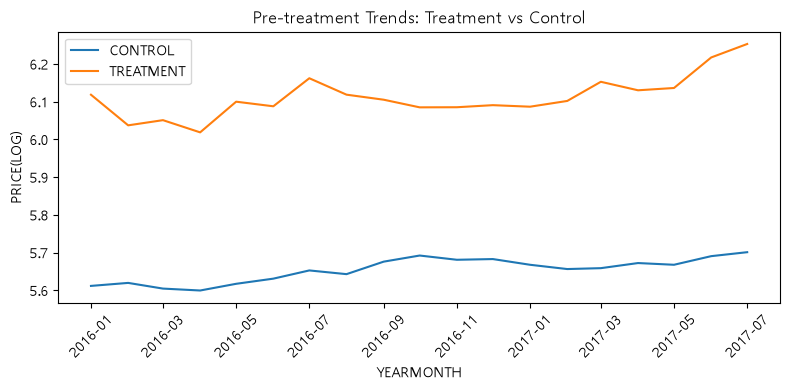

In [15]:
fig = plt.figure(figsize=(8, 4))

for key, grp in df_pre.groupby('TREATMENT'):
    label = 'TREATMENT' if key == 1 else 'CONTROL'
    plt.plot(grp['YEARMONTH'], grp['PRICE'], label=label)

plt.xticks(rotation=45)

plt.xlabel("YEARMONTH")
plt.ylabel("PRICE(LOG)")
plt.title("Pre-treatment Trends: Treatment vs Control")

plt.legend()

plt.tight_layout()
plt.show()

# regression analysis

In [16]:
df_pre = df[df["PERIOD_0"]==1]

In [17]:
FUNCTION = 'PRICE ~ C(REGION_IDX) + C(TIME_IDX) + TREATMENT:TIME_IDX'

kwargs = dict(
    formula=FUNCTION,
    data=df_pre,
)

model = smf.ols(**kwargs)

In [18]:
result = model.fit()

In [19]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     847.8
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:55:56   Log-Likelihood:                 2275.4
No. Observations:                1711   AIC:                            -4325.
Df Residuals:                    1598   BIC:                            -3709.
Df Model:                         112                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.4409    

# regression analysis (clustered standard error)

In [20]:
df_pre = df[df["PERIOD_0"]==1]

In [21]:
FUNCTION = 'PRICE ~ C(REGION_IDX) + C(TIME_IDX) + TREATMENT:TIME_IDX'

kwargs = dict(
    formula=FUNCTION,
    data=df_pre,
)

model = smf.ols(**kwargs)

In [22]:
kwargs = dict(
    cov_type='cluster', 
    cov_kwds={'groups': df_pre['REGION_IDX']},
)

result = model.fit(**kwargs)

In [23]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     1208.
Date:                Tue, 11 Aug 2026   Prob (F-statistic):          1.29e-102
Time:                        16:55:56   Log-Likelihood:                 2275.4
No. Observations:                1711   AIC:                            -4325.
Df Residuals:                    1598   BIC:                            -3709.
Df Model:                         112                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.4409    

c:\Users\jayar\anaconda3\envs\stats\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 112, but rank is 19
  warnings.warn('covariance of constraints does not have full '
